# Week 9: AI Agents in Finance and Data Analytics

## Teaching Notebook: Understanding and Implementing AI Agents for Financial Applications

---

## Table of Contents
1. [Introduction to AI Agents](#intro)
2. [Setting Up the Environment](#setup)
3. [Example 1: Financial Data Analyst Agent](#example1)
4. [Example 2: Portfolio Analysis Agent](#example2)
5. [Example 3: Risk Assessment Agent](#example3)
6. [Example 4: Multi-Agent System for Credit Risk](#example4)
7. [Advanced Topics and Best Practices](#advanced)
8. [Exercises and Extensions](#exercises)

---
<a id='intro'></a>
## 1. Introduction to AI Agents

### What is an AI Agent?

An AI agent is an autonomous system that:
- **Perceives** its environment through inputs (data, queries, market conditions)
- **Reasons** about what actions to take using language models
- **Acts** by using tools (APIs, databases, calculators, code execution)
- **Learns** from feedback to improve performance

### Key Components of AI Agents:

1. **Language Model (LLM)**: The "brain" that processes information and makes decisions
2. **Tools**: External functions the agent can call (APIs, databases, calculators)
3. **Memory**: Short-term (conversation) and long-term (vector databases) storage
4. **Planning**: Ability to break down complex tasks into steps
5. **Action**: Execution of decided actions

### Applications in Finance:

- **Automated Research**: Analyzing earnings reports, SEC filings, news
- **Portfolio Management**: Rebalancing, risk assessment, optimization
- **Risk Analysis**: Credit risk, market risk, operational risk evaluation
- **Trading Strategy**: Backtesting, signal generation, execution
- **Regulatory Compliance**: Monitoring, reporting, documentation
- **Client Services**: Personalized advice, query resolution

---
<a id='setup'></a>
## 2. Setting Up the Environment

We'll use popular libraries for building AI agents and working with financial data.

In [73]:
# !pip install openai pandas numpy yfinance langchain langchain-openai python-dotenv requests groq python-docx

In [74]:
import os, json, re, warnings
import pandas as pd
import numpy as np
import yfinance as yf
import requests as _requests
from datetime import datetime, timedelta
from typing import List, Dict, Any, Optional
warnings.filterwarnings('ignore')
print(f"Environment ready  |  pandas {pd.__version__}  |  numpy {np.__version__}")


Environment ready  |  pandas 2.2.3  |  numpy 2.0.2


### Visualization Setup

Shared dark-theme configuration used by all four plot tools.

In [75]:
# ── VISUALIZATION SETUP (shared across all examples) ──────────────────────
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap

plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor':   '#30363d', 'text.color':     '#e6edf3',
    'axes.labelcolor':  '#e6edf3', 'xtick.color':    '#8b949e',
    'ytick.color':      '#8b949e', 'axes.grid':      True,
    'grid.color':       '#21262d', 'grid.linewidth': 0.5,
    'font.family':      'monospace',
    'legend.facecolor': '#21262d', 'legend.edgecolor': '#30363d',
})
_PAL = ['#58a6ff', '#3fb950', '#f85149', '#d2a8ff', '#ffa657', '#79c0ff']

# ── Plot helpers ─────────────────────────────────────────────────────────────
def _save_fig(fname):
    """tight_layout -> 150-dpi dark save -> show. Returns fname."""
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight', facecolor='#0d1117')
    plt.show()
    return fname

def _cards_panel(ax, cards, title=''):
    """Draw evenly-spaced KPI metric cards on a turned-off axes panel."""
    ax.axis('off')
    n = len(cards); gap = 0.94 / n
    for i, (label, value, color) in enumerate(cards):
        y = 0.95 - i * gap
        ax.add_patch(mpatches.FancyBboxPatch(
            (0.03, y - gap*0.82), 0.94, gap*0.76,
            boxstyle='round,pad=0.015', facecolor='#21262d',
            edgecolor=color, linewidth=1.8, transform=ax.transAxes))
        ax.text(0.10, y - gap*0.30, label, fontsize=8,  color='#8b949e', transform=ax.transAxes)
        ax.text(0.10, y - gap*0.62, value, fontsize=10, fontweight='bold',
                color='#e6edf3', transform=ax.transAxes)
    if title: ax.set_title(title, fontsize=11, pad=8)

# ── Word-document helpers ────────────────────────────────────────────────────
def _style_doc(doc):
    """Apply consistent professional styling to a python-docx Document."""
    from docx.shared import Pt, RGBColor
    NAVY = RGBColor(0x1F, 0x39, 0x64)
    doc.styles['Normal'].font.name = 'Arial'
    doc.styles['Normal'].font.size = Pt(10)
    for lvl, sz in [('Heading 1', 15), ('Heading 2', 12), ('Heading 3', 11)]:
        try:
            s = doc.styles[lvl]; s.font.name = 'Arial'
            s.font.size = Pt(sz); s.font.bold = True; s.font.color.rgb = NAVY
        except: pass

def _tbl_hdr(row, *labels):
    """Bold + blue-shaded header row for a Table Grid table."""
    from docx.shared import RGBColor; from docx.oxml.ns import qn; from docx.oxml import OxmlElement
    for cell, lbl in zip(row.cells, labels):
        cell.text = lbl; run = cell.paragraphs[0].runs[0]; run.bold = True
        shd = OxmlElement('w:shd')
        shd.set(qn('w:val'), 'clear'); shd.set(qn('w:color'), 'auto')
        shd.set(qn('w:fill'), 'DBEAFE')
        cell._tc.get_or_add_tcPr().append(shd)

def _new_doc(heading, subtitle='', margin=1.0):
    """Create a styled Word document with title + optional subtitle."""
    from docx import Document as _Doc; from docx.shared import Inches
    doc = _Doc(); _style_doc(doc)
    sec = doc.sections[0]; sec.left_margin = sec.right_margin = Inches(margin)
    doc.add_heading(heading, 1)
    if subtitle: doc.add_paragraph(subtitle)
    return doc

def _doc_table(doc, headers, rows):
    """Add a Table Grid table with a bold header row + data rows."""
    tbl = doc.add_table(rows=1, cols=len(headers)); tbl.style = 'Table Grid'
    _tbl_hdr(tbl.rows[0], *headers)
    for row_data in rows:
        r = tbl.add_row().cells
        for i, v in enumerate(row_data): r[i].text = str(v)
    return tbl

print(f"Viz theme ready  |  matplotlib {matplotlib.__version__}")
print("Helpers ready: _save_fig  _cards_panel  _new_doc  _doc_table  _style_doc  _tbl_hdr")


Viz theme ready  |  matplotlib 3.10.0
Helpers ready: _save_fig  _cards_panel  _new_doc  _doc_table  _style_doc  _tbl_hdr


### Setting up API Keys

For this notebook, we'll create a simplified agent framework that can work with local LLMs (via Ollama) or cloud APIs.

In [76]:
# ── LLM Backend: 'ollama' | 'groq' | 'openai' ────────────────────────────
LLM_BACKEND     = 'ollama'
OLLAMA_BASE_URL = 'http://localhost:11434'
OLLAMA_MODEL    = 'mistral'              # Apache 2.0  — ollama pull mistral
GROQ_API_KEY    = os.getenv('GROQ_API_KEY', '')
GROQ_MODEL      = 'mixtral-8x7b-32768'  # Apache 2.0  — free at console.groq.com
OPENAI_API_KEY  = os.getenv('OPENAI_API_KEY', '')
OPENAI_MODEL    = 'gpt-4o-mini'

_names = {'ollama': f'Ollama/{OLLAMA_MODEL}', 'groq': f'Groq/{GROQ_MODEL}', 'openai': f'OpenAI/{OPENAI_MODEL}'}
print('Active backend:', _names.get(LLM_BACKEND, LLM_BACKEND))


Active backend: Ollama/mistral


In [77]:
def call_llm(prompt, system_prompt=''):
    """Route prompt to the active backend; return the response string."""
    msgs = ([{'role': 'system', 'content': system_prompt}] if system_prompt else [])          + [{'role': 'user',   'content': prompt}]

    if LLM_BACKEND == 'ollama':
        try:
            full = f"{system_prompt}\n\n{prompt}" if system_prompt else prompt
            r = _requests.post(f"{OLLAMA_BASE_URL}/api/generate",
                json={'model': OLLAMA_MODEL, 'prompt': full, 'stream': False}, timeout=120)
            r.raise_for_status()
            return r.json()['response'].strip()
        except _requests.exceptions.ConnectionError: return '[LLM Error] Ollama not running — run: ollama serve'
        except Exception as e: return f'[LLM Error — Ollama] {e}'

    elif LLM_BACKEND == 'groq':
        try:
            from groq import Groq
            return Groq(api_key=GROQ_API_KEY).chat.completions.create(
                model=GROQ_MODEL, messages=msgs).choices[0].message.content.strip()
        except Exception as e: return f'[LLM Error — Groq] {e}'

    elif LLM_BACKEND == 'openai':
        try:
            from openai import OpenAI
            return OpenAI(api_key=OPENAI_API_KEY).chat.completions.create(
                model=OPENAI_MODEL, messages=msgs).choices[0].message.content.strip()
        except Exception as e: return f'[LLM Error — OpenAI] {e}'

print('LLM says:', call_llm('Say hello in one sentence as a financial analyst AI.'))


LLM says: Hello! I'm here to help you navigate the financial landscape with data-driven insights and strategic analysis. How can I assist you today?


---
<a id='example1'></a>
## 3. Example 1: Financial Data Analyst Agent

This agent can:
- Fetch stock price data
- Calculate financial metrics
- Analyze trends
- Answer questions about the data

### 3.1 Define the Tools

**Tool 1 — `get_stock_data(ticker, period)`**

Fetches historical OHLCV data for a ticker via `yfinance` and returns a summary: current price, period return %, annualised volatility, 52-week high/low, and average daily volume. Use this for a quick price-and-volatility snapshot of a single stock.

In [78]:
def get_stock_data(ticker, period='1y'):
    """Price snapshot: return %, volatility, 52w hi/lo, average volume."""
    try:
        df = yf.Ticker(ticker).history(period=period)
        if df.empty: return {'error': f'No data for {ticker}'}
        p0, p1 = df['Close'].iloc[0], df['Close'].iloc[-1]
        return {
            'ticker': ticker, 'period': period,
            'current_price': round(p1, 2),   'start_price': round(p0, 2),
            'return_pct': round((p1-p0)/p0*100, 2),
            'volatility_annual': round(df['Close'].pct_change().std()*np.sqrt(252)*100, 2),
            'high_52w': round(df['High'].max(), 2), 'low_52w': round(df['Low'].min(), 2),
            'avg_volume': int(df['Volume'].mean()), 'data_points': len(df),
        }
    except Exception as e: return {'error': str(e)}

print(json.dumps(get_stock_data('GE', '1y'), indent=2))


{
  "ticker": "GE",
  "period": "1y",
  "current_price": 320.82,
  "start_price": 242.87,
  "return_pct": 32.09,
  "volatility_annual": 31.09,
  "high_52w": 347.97,
  "low_52w": 231.02,
  "avg_volume": 5354400,
  "data_points": 251
}


**Tool 2 — `calculate_returns(ticker, period)`**

Computes detailed return and risk metrics for a single stock: total return, annualised return, Sharpe ratio (0 % risk-free rate), maximum drawdown, and the count of positive vs negative trading days. Use this when the question is about *how well* a stock has performed or how much risk it carried.

In [79]:
def calculate_returns(ticker, period='1y'):
    """Return metrics: total return, Sharpe ratio, max drawdown, +/- days."""
    try:
        df = yf.Ticker(ticker).history(period=period)
        if df.empty: return {'error': f'No data for {ticker}'}
        r = df['Close'].pct_change().dropna()
        cum = (1+r).cumprod()
        dd  = (cum - cum.cummax()) / cum.cummax()
        return {
            'ticker': ticker, 'period': period,
            'total_return_pct': round((df['Close'].iloc[-1]/df['Close'].iloc[0]-1)*100, 2),
            'avg_daily_return_pct': round(r.mean()*100, 4),
            'annualized_return_pct': round(r.mean()*252*100, 2),
            'sharpe_ratio': round((r.mean()/r.std())*np.sqrt(252), 2) if r.std()>0 else 0,
            'max_drawdown_pct': round(dd.min()*100, 2),
            'positive_days': int((r>0).sum()), 'negative_days': int((r<0).sum()),
        }
    except Exception as e: return {'error': str(e)}

print(json.dumps(calculate_returns('GE', '2y'), indent=2))


{
  "ticker": "GE",
  "period": "2y",
  "total_return_pct": 98.46,
  "avg_daily_return_pct": 0.1584,
  "annualized_return_pct": 39.93,
  "sharpe_ratio": 1.22,
  "max_drawdown_pct": -21.36,
  "positive_days": 278,
  "negative_days": 220
}


**Tool 3 — `compare_stocks(tickers, period)`**

Compares performance across a list of tickers for a given period. Returns return %, annualised volatility, and Sharpe ratio for each stock, sorted from best to worst performer. Useful for ranking peers or building a quick sector snapshot.

In [80]:
def compare_stocks(tickers, period='1y'):
    """Rank tickers by return %; include volatility and Sharpe."""
    rows = []
    for t in tickers:
        d, r = get_stock_data(t, period), calculate_returns(t, period)
        if 'error' not in d and 'error' not in r:
            rows.append({'ticker': t, 'return_pct': d['return_pct'],
                         'volatility': d['volatility_annual'],
                         'sharpe_ratio': r['sharpe_ratio'], 'max_drawdown': r['max_drawdown_pct']})
    rows.sort(key=lambda x: x['return_pct'], reverse=True)
    return {'period': period, 'num_stocks': len(rows), 'comparison': rows,
            'best_performer':  rows[0]['ticker'] if rows else None,
            'worst_performer': rows[-1]['ticker'] if rows else None}

print(json.dumps(compare_stocks(['AAPL', 'MSFT', 'GOOGL'], '6mo'), indent=2))


{
  "period": "6mo",
  "num_stocks": 3,
  "comparison": [
    {
      "ticker": "GOOGL",
      "return_pct": 24.06,
      "volatility": 29.0,
      "sharpe_ratio": 1.68,
      "max_drawdown": -20.37
    },
    {
      "ticker": "AAPL",
      "return_pct": 10.59,
      "volatility": 22.21,
      "sharpe_ratio": 1.05,
      "max_drawdown": -13.8
    },
    {
      "ticker": "MSFT",
      "return_pct": -11.88,
      "volatility": 29.65,
      "sharpe_ratio": -0.73,
      "max_drawdown": -27.32
    }
  ],
  "best_performer": "GOOGL",
  "worst_performer": "MSFT"
}


**Tool 4 — `plot_stock_comparison(tickers, period)`**

Fetches comparison data and renders a 3-panel chart (return bars, risk-return scatter, Sharpe bars).
Registered in `LLMFinancialAnalystAgent.tools` — the agent calls it automatically after every
`compare_stocks` invocation so visualisation is part of the workflow, not a post-processing step.

In [81]:
def plot_stock_comparison(tickers, period='6mo', analysis_text=None):
    """Tool 4: 3-panel comparison chart + Word report (.docx)."""
    from docx.shared import Inches
    if isinstance(tickers, str): tickers = [tickers]
    comp = compare_stocks(tickers, period)['comparison']
    tks2 = [c['ticker']       for c in comp]
    rets = [c['return_pct']   for c in comp]
    vols = [c['volatility']   for c in comp]
    shps = [c['sharpe_ratio'] for c in comp]

    # ── CHART ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')

    # Panel 1: Returns bar
    b1 = axes[0].bar(tks2, rets, color=[_PAL[1] if r>=0 else _PAL[2] for r in rets],
                     edgecolor='#21262d', width=0.5)
    axes[0].axhline(0, color='#8b949e', lw=0.7)
    axes[0].set_title(f'Return (%) — {period}', fontsize=11, pad=8)
    for b, v in zip(b1, rets):
        axes[0].text(b.get_x()+b.get_width()/2, v+(0.5 if v>=0 else -1.0),
                     f'{v:+.1f}%', ha='center', va='bottom' if v>=0 else 'top',
                     fontsize=10, fontweight='bold', color='#e6edf3')

    # Panel 2: Risk-return scatter
    for t, r, v, c in zip(tks2, rets, vols, _PAL):
        axes[1].scatter(v, r, s=260, c=c, zorder=5, edgecolors='white', lw=1.5)
        axes[1].annotate(t, (v, r), xytext=(6, 4), textcoords='offset points',
                         fontsize=10, fontweight='bold', color='#e6edf3')
    axes[1].axhline(0, color='#8b949e', lw=0.6, ls='--')
    axes[1].set_xlabel('Volatility (%)'); axes[1].set_ylabel('Return (%)')
    axes[1].set_title('Risk-Return Tradeoff', fontsize=11, pad=8)

    # Panel 3: Sharpe bar
    b3 = axes[2].bar(tks2, shps, color=[_PAL[1] if s>=0 else _PAL[2] for s in shps],
                     edgecolor='#21262d', width=0.5)
    axes[2].axhline(0, color='#8b949e', lw=0.7)
    axes[2].set_title('Sharpe Ratio', fontsize=11, pad=8)
    for b, v in zip(b3, shps):
        axes[2].text(b.get_x()+b.get_width()/2, v+(0.02 if v>=0 else -0.07),
                     f'{v:.2f}', ha='center', va='bottom' if v>=0 else 'top',
                     fontsize=10, fontweight='bold', color='#e6edf3')

    fig.suptitle(f'Stock Comparison: {" | ".join(tks2)}  ({period})',
                 fontsize=13, fontweight='bold', color='#e6edf3', y=1.02)
    fname = f"chart_{'_'.join(tks2)}_{period}.png"
    _save_fig(fname)

    # ── WORD REPORT ────────────────────────────────────────────────────────
    doc = _new_doc(f'Stock Comparison Report — {period.upper()}',
                   f'Tickers: {" | ".join(tks2)}  ·  Period: {period}'
                   f'  ·  Generated: {datetime.now():%Y-%m-%d}')

    doc.add_heading('Performance Metrics', 2)
    _doc_table(doc,
        ['Ticker', 'Return (%)', 'Volatility (%)', 'Sharpe', 'Max Drawdown (%)'],
        [[c['ticker'], f"{c['return_pct']:+.2f}", f"{c['volatility']:.2f}",
          f"{c['sharpe_ratio']:.2f}", f"{c['max_drawdown']:.2f}"] for c in comp])

    doc.add_heading('Comparison Chart', 2)
    doc.add_picture(fname, width=Inches(6.0))

    doc.add_heading('Key Takeaways', 2)
    for line in [
        f"Best performer:  {comp[0]['ticker']}  —  "
        f"{comp[0]['return_pct']:+.1f}% return, Sharpe {comp[0]['sharpe_ratio']:.2f}",
        f"Worst performer: {comp[-1]['ticker']}  —  "
        f"{comp[-1]['return_pct']:+.1f}% return, Sharpe {comp[-1]['sharpe_ratio']:.2f}",
        f"Avg volatility across peers: {sum(vols)/len(vols):.1f}%",
    ]: doc.add_paragraph(line)

    if analysis_text:
        doc.add_heading('Agent Analysis', 2)
        doc.add_paragraph(str(analysis_text))

    dname = fname.replace('.png', '.docx')
    doc.save(dname)
    print(f"Chart saved → {fname}\nWord report saved → {dname}")
    return {'status': 'done', 'chart': fname, 'report': dname,
            'best': comp[0]['ticker'], 'worst': comp[-1]['ticker']}

print("Tool 4 — plot_stock_comparison() ready  (chart + .docx).")


Tool 4 — plot_stock_comparison() ready  (chart + .docx).


### 3.2 Define the Agent

The agent follows the **ReAct loop** (Reason → Act → Observe):

```
User query
    │
    ▼
 LLM reads tool descriptions → decides which tool to call
    │
    ▼
 Tool executes  →  result returned
    │
    ▼
 LLM interprets result  →  professional analysis
```

The LLM acts as the **brain** — it decides what to do and writes the final
answer. The tools act as the **hands** — they fetch real data the LLM cannot
access on its own (live prices, returns, comparisons).

Key design choices:
- A **system prompt** describes the available tools and expected output format.
- The first LLM call produces a structured `TOOL: name(args)` command.
- The second LLM call receives the tool output and writes the final analysis.
- `conversation_history` stores every turn for later review.

**`LLMFinancialAnalystAgent` — the agent class**

Wraps the three tools above into a ReAct loop driven by a real LLM. The `SYSTEM_PROMPT` tells the model what tools exist and the exact `TOOL: name(args)` format it must use. `run()` handles the two-step call: first to decide which tool to invoke, second to interpret the result and write the final answer. `conversation_history` logs every turn for auditing.

In [82]:
class LLMFinancialAnalystAgent:
    """ReAct agent: up to 3 LLM calls per query — Reason → Act → Observe → Visualise."""
    SYSTEM_PROMPT = """You are a professional financial data analyst AI.
Tools available:
  1. get_stock_data(ticker, period)              — price, return %, volatility, 52w hi/lo, volume
  2. calculate_returns(ticker, period)           — Sharpe, max drawdown, annualised return
  3. compare_stocks(tickers_list, period)        — ranked comparison of return, vol, Sharpe
  4. plot_stock_comparison(tickers_list, period) — render a visual comparison chart (3-panel)

Rules:
- If live data is needed respond ONLY with: TOOL: tool_name(arg1, arg2)
- Use uppercase tickers. Valid periods: 1d 5d 1mo 3mo 6mo 1y 2y 5y.
- After any compare_stocks call, also call plot_stock_comparison with the same args.
- If the question cannot be answered with these tools, explain why clearly."""

    def __init__(self, name='LLMFinancialAnalyst'):
        self.name = name
        self.tools = {
            'get_stock_data':        get_stock_data,
            'calculate_returns':     calculate_returns,
            'compare_stocks':        compare_stocks,
            'plot_stock_comparison': plot_stock_comparison,  # ← Tool 4: visualisation
        }
        self.conversation_history = []

print("LLMFinancialAnalystAgent — class shell ready.")


LLMFinancialAnalystAgent — class shell ready.


**`_parse_tool_call(text)`**

Scans the LLM's raw response for a `TOOL: name(args)` pattern. Handles quoted strings, nested lists, and comma-separated arguments. Returns a dict with `tool` (name) and `args` (list), or `None` if the LLM responded directly without requesting a tool.

In [83]:
def _parse_tool_call(self, text):
    m = re.search(r'TOOL:\s*(\w+)\(([^)]*)\)', text)
    if not m: return None
    tool, args_str = m.group(1), m.group(2).strip()
    args, cur, depth, in_q, qc = [], '', 0, False, None
    for ch in args_str + ',':
        if ch in ('"', "'") and not in_q: in_q, qc = True, ch; cur += ch
        elif ch == qc and in_q:           in_q, qc = False, None; cur += ch
        elif ch == '[' and not in_q:      depth += 1; cur += ch
        elif ch == ']' and not in_q:      depth -= 1; cur += ch
        elif ch == ',' and depth == 0 and not in_q:
            a = cur.strip().strip("'\"")
            if a: args.append([x.strip().strip("'\"") for x in a[1:-1].split(',')] if a.startswith('[') else a)
            cur = ''
        else: cur += ch
    return {'tool': tool, 'args': args}

LLMFinancialAnalystAgent._parse_tool_call = _parse_tool_call


**`run(user_query)`**

The main ReAct loop — the only method students need to call. Makes two LLM requests: the first decides which tool to use (or answers directly if no tool applies), the second interprets the tool output and writes the final analysis. Every turn is appended to `conversation_history`.

In [84]:
def run(self, user_query):
    """ReAct loop: Reason → Act → Observe  (auto-visualises after compare_stocks)."""
    print(f"\n[{self.name}] Query: {user_query}")
    resp = call_llm(user_query, system_prompt=self.SYSTEM_PROMPT)
    print(f"[{self.name}] LLM → {resp[:120].strip()}")
    tc = self._parse_tool_call(resp)
    if tc and tc['tool'] in self.tools:
        print(f"[{self.name}] Calling: {tc['tool']}({tc['args']})")
        result = self.tools[tc['tool']](*tc['args'])
        final = call_llm(
            f"Original question: {user_query}\nTool: {tc['tool']}\n"
            f"Result:\n{json.dumps(result, indent=2)}\n\nWrite a concise professional analysis.",
            system_prompt=self.SYSTEM_PROMPT)
        # ── Auto-visualise whenever a stock comparison is returned ──────
        if tc['tool'] == 'compare_stocks':
            print(f"[{self.name}] Calling: plot_stock_comparison (Tool 4 — auto-viz)")
            self.tools['plot_stock_comparison'](*tc['args'], analysis_text=final)
        self.conversation_history.append({'query': user_query, 'tool': tc['tool'], 'response': final})
        return final
    self.conversation_history.append({'query': user_query, 'response': resp})
    return resp

LLMFinancialAnalystAgent.run = run
print("LLMFinancialAnalystAgent ready  (Tools 1-3: data  |  Tool 4: visualisation).")


LLMFinancialAnalystAgent ready  (Tools 1-3: data  |  Tool 4: visualisation).


### 3.3 Test the Agent

**Demo — Run the LLM Agent**

Three test queries exercise all three tools and one out-of-scope question. Watch the printed trace to see which tool the LLM selects and how it phrases the final analysis. The third query (Book-to-Market) has no matching tool — the LLM should explain its limitation rather than returning wrong data.


TEST 1 — stock data

[LLMFinancialAnalyst] Query: How has Apple stock performed over the past year?
[LLMFinancialAnalyst] LLM → TOOL: get_stock_data('AAPL', '1y')

Here is the data for Apple stock over the past year:

* Price: $132.89
* Return %: 7
[LLMFinancialAnalyst] Calling: get_stock_data(['AAPL', '1y'])
Based on the data obtained from the AAPL stock performance over the past year (1y), the stock has shown a significant growth of 56.91%. The current price stands at $312.51, with a high for the past 52 weeks reaching $313.26 and a low of $194.3. This equates to an annualized volatility of 22.08%, indicative of moderate risk associated with this investment. The average daily volume for this period was approximately 49.5 million shares. In conclusion, AAPL has demonstrated robust growth over the past year, making it a potentially attractive investment opportunity for those seeking capital appreciation. However, the relatively high volatility should be taken into account when conside

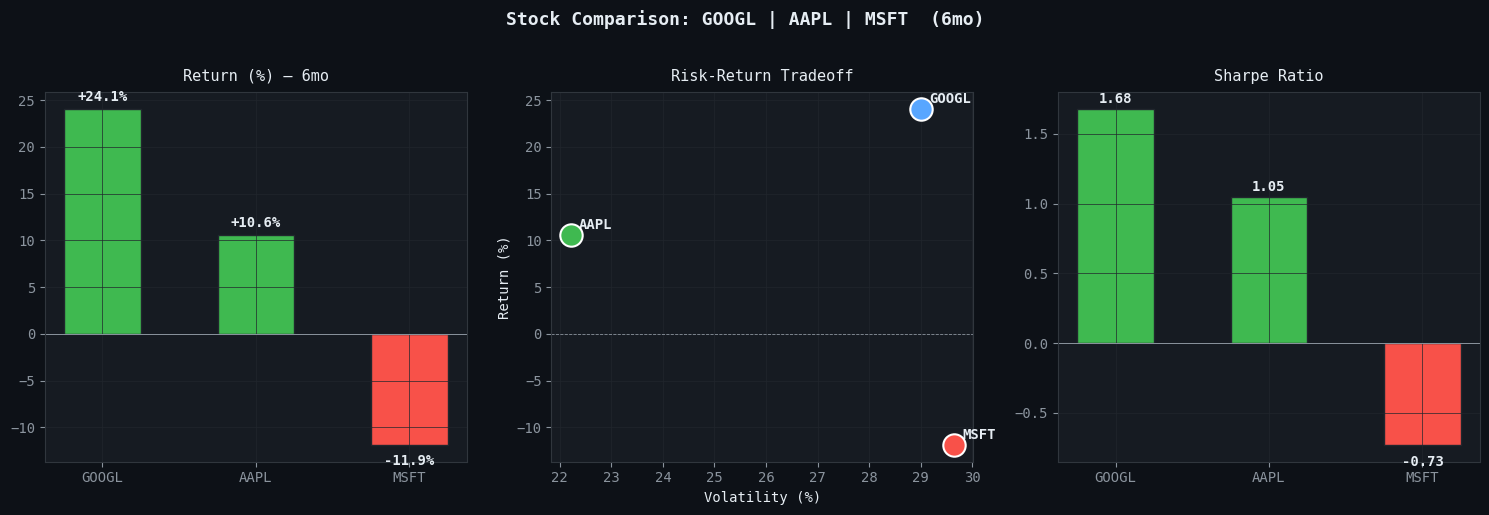

Chart saved → chart_GOOGL_AAPL_MSFT_6mo.png
Word report saved → chart_GOOGL_AAPL_MSFT_6mo.docx
In the comparison of AAPL, MSFT, and GOOGL over the last six months, it is evident that GOOGL has demonstrated the strongest performance with a return of 24.06%, followed by AAPL with a return of 10.59%. Conversely, Microsoft (MSFT) experienced a negative return of -11.88% over the same period.

It's important to note that GOOGL also had the lowest volatility among the three stocks at 29.0%, while AAPL and MSFT exhibited volatilities of 22.21% and 29.65%, respectively. The higher the volatility, the more the stock price fluctuates over time.

In terms of risk-adjusted returns, represented by the Sharpe ratio, GOOGL and AAPL outperformed MSFT with ratios of 1.68 and 1.05 compared to -0.73 for Microsoft. A higher Sharpe ratio indicates a higher return for a given level of risk.

When considering drawdowns, GOOGL experienced the highest negative peak at -20.37%, followed by AAPL (-13.8%) and MSF

In [85]:
llm_agent = LLMFinancialAnalystAgent()
for label, query in [
    ("TEST 1 — stock data",   "How has Apple stock performed over the past year?"),
    ("TEST 2 — comparison",   "Compare AAPL, MSFT and GOOGL over the last 6 months."),
    ("TEST 3 — out-of-scope", "What is the Book-to-Market ratio for Apple?"),
]:
    print(f"\n{'='*70}\n{label}\n{'='*70}")
    print(llm_agent.run(query))
print(f"\nConversation history: {len(llm_agent.conversation_history)} turns recorded.")


---
<a id='example2'></a>
## 4. Example 2: Portfolio Analysis Agent

This agent manages a portfolio and can:
- Calculate portfolio value
- Assess risk metrics
- Suggest rebalancing
- Track performance

### 4.1 Define the Tools

**Tool 1 — `calculate_portfolio_value()`**

Fetches the latest closing price for each holding via `yfinance` and computes dollar value and allocation % per position. Returns a dict with total portfolio value, number of positions, and per-holding detail.

In [86]:
def calculate_portfolio_value(self):
    """Fetch live prices → dollar value & allocation % per holding."""
    total, holdings = 0, []
    for ticker, shares in self.portfolio.items():
        price = yf.Ticker(ticker).history(period='1d')['Close'].iloc[-1]
        val   = shares * price
        total += val
        holdings.append({'ticker': ticker, 'shares': shares,
                         'price': round(price, 2), 'value': round(val, 2)})
    for h in holdings:
        h['allocation_pct'] = round(h['value']/total*100, 2)
    return {'total_value': round(total, 2), 'num_positions': len(holdings), 'holdings': holdings}


**Tool 2 — `calculate_portfolio_metrics(period)`**

Builds a dollar-weighted return series for the portfolio and computes total return, annualised return, annualised volatility, Sharpe ratio (0% risk-free rate), and maximum drawdown over the chosen period.

In [87]:
def calculate_portfolio_metrics(self, period='1y'):
    """Weighted returns → annual return, volatility, Sharpe, max drawdown."""
    prices = pd.DataFrame({t: yf.Ticker(t).history(period=period)['Close']
                           for t in self.portfolio})
    if prices.empty: return {'error': 'No price data'}
    ret = prices.pct_change().dropna()
    w   = np.array([h['allocation_pct']/100
                    for h in self.calculate_portfolio_value()['holdings']])
    pr  = ret.dot(w)
    cum = (1+pr).cumprod()
    dd  = (cum - cum.cummax()) / cum.cummax()
    return {
        'period': period,
        'total_return_pct':     round(((1+pr).prod()-1)*100, 2),
        'annualized_return_pct': round(pr.mean()*252*100, 2),
        'volatility_pct':       round(pr.std()*np.sqrt(252)*100, 2),
        'sharpe_ratio':         round((pr.mean()/pr.std())*np.sqrt(252), 2) if pr.std()>0 else 0,
        'max_drawdown_pct':     round(dd.min()*100, 2),
        'correlation_matrix':   ret.corr().round(3).to_dict(),
    }


**Tool 3 — `suggest_rebalancing(target_allocation)`**

Compares current allocations against a target (a dict of ticker → %) and generates buy/sell orders for positions where drift exceeds 1 pp. Returns the action, number of shares, and dollar value per trade.

In [88]:
def suggest_rebalancing(self, target_allocation):
    """Generate BUY/SELL orders to reach target allocation (ignores drifts ≤ 1 pp)."""
    cur, total = self.calculate_portfolio_value(), None
    total = cur['total_value']
    suggestions = []
    for h in cur['holdings']:
        t, cpct = h['ticker'], h['allocation_pct']
        tpct = target_allocation.get(t, 0)
        if abs(cpct - tpct) > 1:
            diff = (tpct - cpct) / 100 * total
            suggestions.append({'ticker': t, 'current_allocation': cpct,
                                 'target_allocation': tpct,
                                 'action': 'BUY' if diff > 0 else 'SELL',
                                 'shares': round(abs(diff)/h['price'], 2),
                                 'value':  round(abs(diff), 2)})
    return {'portfolio_value': total, 'num_trades': len(suggestions), 'suggestions': suggestions}


**Tool 4 — `generate_report()`**

Calls `calculate_portfolio_value` and `calculate_portfolio_metrics` and formats the results into a readable text report with a holdings table and 1-year performance summary.

In [89]:
def generate_report(self):
    """Combine portfolio value + 1-year metrics into a formatted text report."""
    v, m = self.calculate_portfolio_value(), self.calculate_portfolio_metrics('1y')
    lines = ['\n' + '='*60, 'PORTFOLIO ANALYSIS REPORT', '='*60,
             f"\nTotal Portfolio Value: ${v['total_value']:,.2f}",
             f"Number of Positions:  {v['num_positions']}\n", 'HOLDINGS:', '-'*60]
    for h in v['holdings']:
        lines.append(f"{h['ticker']:6} | {h['shares']:6.1f} shares | "
                     f"${h['price']:8.2f} | ${h['value']:12,.2f} | {h['allocation_pct']:5.1f}%")
    lines += ['\n' + '='*60, 'PERFORMANCE METRICS (1 Year)', '='*60,
              f"Total Return:      {m['total_return_pct']:.2f}%",
              f"Annualized Return: {m['annualized_return_pct']:.2f}%",
              f"Volatility:        {m['volatility_pct']:.2f}%",
              f"Sharpe Ratio:      {m['sharpe_ratio']:.2f}",
              f"Maximum Drawdown:  {m['max_drawdown_pct']:.2f}%", '='*60]
    return '\n'.join(lines)


**Tool 5 — `plot_portfolio_report(self)`**

Calls `calculate_portfolio_value` and `calculate_portfolio_metrics` internally, then renders a
3-panel chart: donut allocation, current-vs-equal-weight bars, and a performance metric card deck.
Registered as a method on `PortfolioAgent` — called explicitly after `generate_report()`.

In [90]:
def plot_portfolio_report(self):
    """Tool 5: Allocation chart + Word portfolio report (.docx)."""
    from docx.shared import Inches
    val   = self.calculate_portfolio_value()
    met   = self.calculate_portfolio_metrics('1y')
    tks_p = [h['ticker']         for h in val['holdings']]
    alloc = [h['allocation_pct'] for h in val['holdings']]
    eq    = [round(100/len(tks_p))] * len(tks_p)

    # ── CHART ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor='#0d1117')

    # Panel 1: Donut
    _, _, autos = axes[0].pie(alloc, labels=tks_p, autopct='%1.1f%%',
        colors=_PAL[:len(tks_p)], startangle=90, pctdistance=0.72,
        wedgeprops=dict(width=0.52, edgecolor='#0d1117', linewidth=2))
    for a in autos: a.set_fontsize(9); a.set_color('#e6edf3')
    axes[0].add_patch(plt.Circle((0, 0), 0.42, fc='#161b22'))
    axes[0].text(0,  0.06, f"${val['total_value']:,.0f}", ha='center', va='center',
                 fontsize=10, fontweight='bold', color='#e6edf3')
    axes[0].text(0, -0.10, 'portfolio value', ha='center', va='center', fontsize=7, color='#8b949e')
    axes[0].set_title('Current Allocation', fontsize=11, pad=10)

    # Panel 2: Current vs equal-weight
    x2 = np.arange(len(tks_p)); w2 = 0.35
    axes[1].bar(x2-w2/2, alloc, width=w2, color=_PAL[0], alpha=0.9, edgecolor='#21262d', label='Current')
    axes[1].bar(x2+w2/2, eq,   width=w2, color=_PAL[3], alpha=0.9, edgecolor='#21262d', label='Equal-weight')
    axes[1].set_xticks(x2); axes[1].set_xticklabels(tks_p)
    axes[1].legend(framealpha=0.4, fontsize=8); axes[1].set_ylabel('Allocation (%)')
    axes[1].set_title('Current vs Equal-Weight', fontsize=11, pad=8)
    for xi, (c, e) in enumerate(zip(alloc, eq)):
        axes[1].text(xi-w2/2, c+0.3, f'{c:.1f}', ha='center', fontsize=8, color='#e6edf3')
        axes[1].text(xi+w2/2, e+0.3, f'{e:.0f}', ha='center', fontsize=8, color='#e6edf3')

    # Panel 3: KPI cards
    _cards_panel(axes[2], [
        ('Total Return',  f"{met['total_return_pct']:+.1f}%",     _PAL[1]),
        ('Ann. Return',   f"{met['annualized_return_pct']:+.1f}%", _PAL[1]),
        ('Volatility',    f"{met['volatility_pct']:.1f}%",         _PAL[4]),
        ('Sharpe Ratio',  f"{met['sharpe_ratio']:.2f}",            _PAL[0]),
        ('Max Drawdown',  f"{met['max_drawdown_pct']:.1f}%",       _PAL[2]),
    ], title='1-Year Performance')

    fig.suptitle(f'Portfolio Report — {len(tks_p)} positions  |  ${val["total_value"]:,.0f}',
                 fontsize=13, fontweight='bold', color='#e6edf3', y=1.02)
    _save_fig('portfolio_report.png')

    # ── WORD REPORT ────────────────────────────────────────────────────────
    agent_report = self.generate_report()
    doc = _new_doc('Portfolio Analysis Report',
                   f'Positions: {" | ".join(tks_p)}  ·  Total Value: ${val["total_value"]:,.2f}'
                   f'  ·  Generated: {datetime.now():%Y-%m-%d}')

    doc.add_heading('Holdings', 2)
    _doc_table(doc,
        ['Ticker', 'Shares', 'Price ($)', 'Value ($)', 'Allocation (%)'],
        [[h['ticker'], f"{h['shares']:.1f}", f"{h['price']:,.2f}",
          f"{h['value']:,.2f}", f"{h['allocation_pct']:.1f}%"] for h in val['holdings']])

    doc.add_heading('1-Year Performance Metrics', 2)
    _doc_table(doc, ['Metric', 'Value'], [
        ('Total Return',         f"{met['total_return_pct']:+.2f}%"),
        ('Annualised Return',    f"{met['annualized_return_pct']:+.2f}%"),
        ('Portfolio Volatility', f"{met['volatility_pct']:.2f}%"),
        ('Sharpe Ratio',         f"{met['sharpe_ratio']:.2f}"),
        ('Maximum Drawdown',     f"{met['max_drawdown_pct']:.2f}%"),
    ])

    doc.add_heading('Portfolio Chart', 2)
    doc.add_picture('portfolio_report.png', width=Inches(6.0))

    doc.add_heading('Agent Analysis', 2)
    doc.add_paragraph(agent_report)

    doc.save('portfolio_report.docx')
    print("Chart saved → portfolio_report.png\nWord report saved → portfolio_report.docx")
    return "Portfolio chart + Word report generated."


### 4.2 Define the Agent

**`PortfolioAgent` — portfolio management agent**

Manages a dict of `{ticker: shares}` positions. Key methods:
- `calculate_portfolio_value()` — fetches live prices and computes dollar value and allocation % per holding.
- `calculate_portfolio_metrics()` — computes portfolio-level return, volatility, Sharpe ratio, and max drawdown using dollar-weighted returns.
- `suggest_rebalancing(target)` — generates buy/sell orders to reach a target allocation.
- `generate_report()` — combines the above into a formatted text report.

In [91]:
class PortfolioAgent:
    """Portfolio management agent — 5 tools (4 data + 1 visualisation)."""
    def __init__(self, portfolio):
        self.portfolio     = portfolio
        self.initial_value = None

    calculate_portfolio_value   = calculate_portfolio_value
    calculate_portfolio_metrics = calculate_portfolio_metrics
    suggest_rebalancing         = suggest_rebalancing
    generate_report             = generate_report
    plot_portfolio_report       = plot_portfolio_report     # ← Tool 5: visualisation

print("PortfolioAgent ready  (Tools 1-4: data  |  Tool 5: visualisation).")


PortfolioAgent ready  (Tools 1-4: data  |  Tool 5: visualisation).


### 4.3 Test the Agent

**Test — Portfolio Report**

Instantiates the agent with a four-stock portfolio and calls `generate_report()`. The output shows current holdings, dollar values, allocation percentages, and a one-year performance summary (return, volatility, Sharpe ratio, max drawdown).


PORTFOLIO ANALYSIS REPORT

Total Portfolio Value: $17,718.49
Number of Positions:  4

HOLDINGS:
------------------------------------------------------------
AAPL   |   15.0 shares | $  312.51 | $    4,687.65 |  26.5%
MSFT   |   20.0 shares | $  426.99 | $    8,539.80 |  48.2%
GOOGL  |    8.0 shares | $  390.13 | $    3,121.04 |  17.6%
AMZN   |    5.0 shares | $  274.00 | $    1,370.00 |   7.7%

PERFORMANCE METRICS (1 Year)
Total Return:      31.39%
Annualized Return: 28.90%
Volatility:        16.56%
Sharpe Ratio:      1.75
Maximum Drawdown:  -19.97%

REBALANCING SUGGESTIONS
Portfolio Value: $17,718.49   Trades needed: 4

AAPL   | BUY    2.01 shares |  26.5% →  30.0% | $    627.23
MSFT   | SELL   7.55 shares |  48.2% →  30.0% | $  3,224.77
GOOGL  | BUY    3.36 shares |  17.6% →  25.0% | $  1,309.40
AMZN   | BUY    4.70 shares |   7.7% →  15.0% | $  1,288.13

[PortfolioAgent] Calling: plot_portfolio_report (Tool 5 — visualisation)


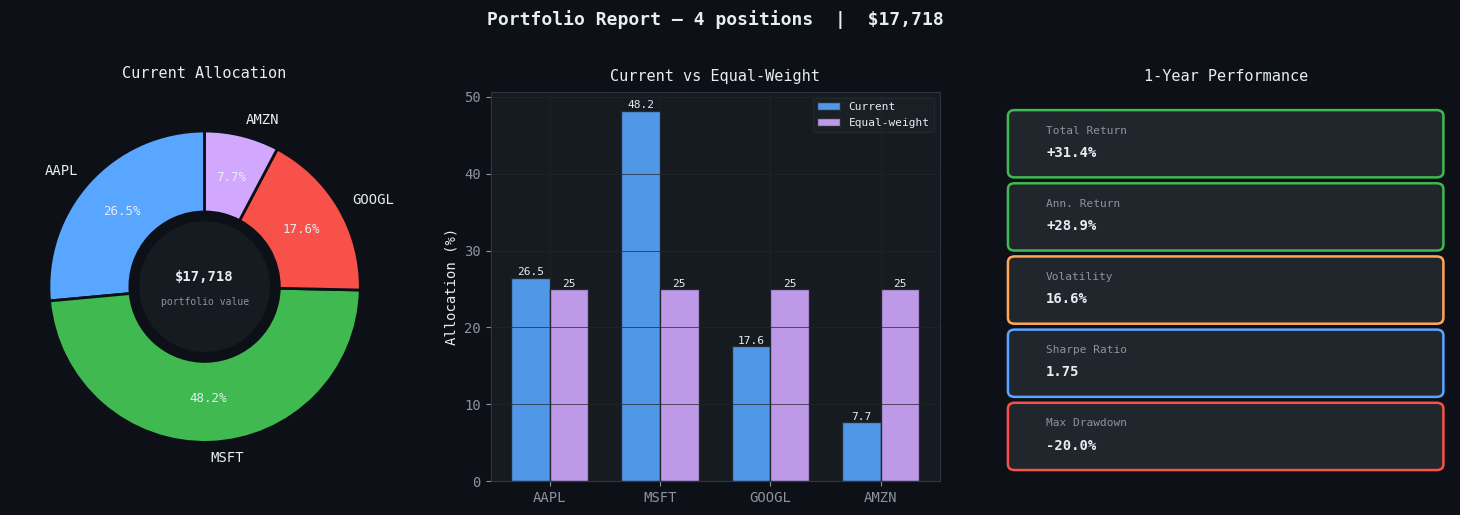

Chart saved → portfolio_report.png
Word report saved → portfolio_report.docx


'Portfolio chart + Word report generated.'

In [92]:
my_portfolio = {'AAPL': 15, 'MSFT': 20, 'GOOGL': 8, 'AMZN': 5}
portfolio_agent = PortfolioAgent(my_portfolio)
print(portfolio_agent.generate_report())
target = {'AAPL': 30, 'MSFT': 30, 'GOOGL': 25, 'AMZN': 15}
reb    = portfolio_agent.suggest_rebalancing(target)
print(f"\nREBALANCING SUGGESTIONS\n{'='*60}")
print(f"Portfolio Value: ${reb['portfolio_value']:,.2f}   Trades needed: {reb['num_trades']}\n")
for s in reb['suggestions']:
    print(f"{s['ticker']:6} | {s['action']:4} {s['shares']:6.2f} shares | "
          f"{s['current_allocation']:5.1f}% → {s['target_allocation']:5.1f}% | ${s['value']:10,.2f}")
# ── Tool 5: Visualise ───────────────────────────────────────────────────────
print("\n[PortfolioAgent] Calling: plot_portfolio_report (Tool 5 — visualisation)")
portfolio_agent.plot_portfolio_report()


**Test — Portfolio Rebalancing**

Compares current allocations against a target and calculates the exact number of shares to buy or sell for each position. Only trades where the drift exceeds 1 percentage point are surfaced, keeping transaction costs in mind.

---
<a id='example3'></a>
## 5. Example 3: Risk Assessment Agent

This agent specializes in risk analysis:
- Value at Risk (VaR) calculation
- Stress testing
- Scenario analysis
- Risk decomposition

### 5.1 Define the Tools

**Tool 1 — `calculate_var(period, horizon_days)`**

Historical-simulation Value at Risk (VaR) and Conditional VaR (Expected Shortfall). Scales the 1-day distribution to any horizon using the square-root-of-time rule. Returns both the % loss and the dollar amount at the configured confidence level.

In [93]:
def calculate_var(self, period='1y', horizon_days=1):
    """Historical-simulation VaR & CVaR at self.confidence_level."""
    prices = pd.DataFrame({t: yf.Ticker(t).history(period=period)['Close']
                           for t in self.portfolio})
    if prices.empty: return {'error': 'No price data'}
    ret  = prices.pct_change().dropna()
    pval = sum(self.portfolio[t] * prices[t].iloc[-1] for t in self.portfolio)
    pr   = (ret * [self.portfolio[t] for t in self.portfolio]).sum(axis=1) / pval
    pr   = pr * np.sqrt(horizon_days)
    var_r  = np.percentile(pr, (1-self.confidence_level)*100)
    cvar_r = pr[pr <= var_r].mean()
    return {
        'portfolio_value': round(pval, 2), 'confidence_level': self.confidence_level,
        'horizon_days': horizon_days,
        'var_pct': round(var_r*100, 2),   'var_dollar':  round(abs(var_r*pval), 2),
        'cvar_pct': round(cvar_r*100, 2), 'cvar_dollar': round(abs(cvar_r*pval), 2),
        'interpretation': (f"{(1-self.confidence_level)*100:.0f}% chance of losing "
                           f"> ${abs(var_r*pval):,.2f} in {horizon_days} day(s)"),
    }


**Tool 2 — `stress_test(scenarios)`**

Applies a dict of named market shocks (e.g. `{'Crash': -30, 'Rally': +10}`) to the current portfolio value. Returns new portfolio value and P&L for each scenario — useful for communicating downside risk to clients.

In [94]:
def stress_test(self, scenarios):
    """Apply % market shocks → new portfolio value & P&L per scenario."""
    pval = sum(yf.Ticker(t).history(period='1d')['Close'].iloc[-1] * s
               for t, s in self.portfolio.items())
    results = [{'scenario': name, 'shock_pct': pct,
                'new_value':    round(pval*(1+pct/100), 2),
                'loss_dollar':  round(pval*pct/100, 2), 'loss_pct': pct}
               for name, pct in scenarios.items()]
    return {'current_value': round(pval, 2), 'num_scenarios': len(results), 'scenarios': results}


**Tool 3 — `analyze_correlations(period)`**

Computes pairwise return correlations for all holdings and derives an overall diversification score (100 = fully uncorrelated, 0 = perfect co-movement). Higher scores indicate the portfolio benefits more from diversification.

In [95]:
def analyze_correlations(self, period='1y'):
    """Pairwise return correlations + diversification score (100 = uncorrelated)."""
    prices = pd.DataFrame({t: yf.Ticker(t).history(period=period)['Close']
                           for t in self.portfolio})
    if prices.empty: return {'error': 'No price data'}
    corr = prices.pct_change().dropna().corr()
    tks  = list(self.portfolio.keys())
    pairs = sorted(
        [{'pair': f'{tks[i]}-{tks[j]}', 'correlation': round(corr.iloc[i,j], 3)}
         for i in range(len(tks)) for j in range(i+1, len(tks))],
        key=lambda x: abs(x['correlation']), reverse=True)
    avg = np.mean([p['correlation'] for p in pairs])
    return {'period': period, 'num_assets': len(tks), 'avg_correlation': round(avg, 3),
            'correlation_pairs': pairs, 'diversification_score': round((1-avg)*100, 1)}


**Tool 4 — `generate_risk_report()`**

Orchestrates the three methods above and formats the results into a single printable risk report covering VaR, stress tests, and diversification analysis.

In [96]:
def generate_risk_report(self):
    """Run VaR, stress test, correlations; return a combined report string."""
    v = self.calculate_var()
    s = self.stress_test({'Severe Market Crash': -30, 'Market Correction': -15,
                          'Mild Downturn': -5, 'Market Rally': 10})
    c = self.analyze_correlations()
    sep = '='*70
    r  = f"\n{sep}\nRISK ASSESSMENT REPORT\n{sep}\n\n"
    r += f"VaR ({v['confidence_level']*100:.0f}%, {v['horizon_days']}-day)\n" + '-'*70 + '\n'
    r += f"Portfolio Value : ${v['portfolio_value']:,.2f}\n"
    r += f"VaR             : ${v['var_dollar']:,.2f}  ({v['var_pct']:.2f}%)\n"
    r += f"CVaR (ES)       : ${v['cvar_dollar']:,.2f}  ({v['cvar_pct']:.2f}%)\n"
    r += f"Interpretation  : {v['interpretation']}\n"
    r += f"\n{sep}\nSTRESS TEST\n{sep}\n"
    for sc in s['scenarios']:
        r += f"  {sc['scenario']:25} ({sc['shock_pct']:+3.0f}%): ${sc['new_value']:>12,.2f}  ({sc['loss_dollar']:+,.2f})\n"
    r += f"\n{sep}\nDIVERSIFICATION\n{sep}\n"
    r += f"Avg Correlation : {c['avg_correlation']:.3f}\n"
    r += f"Diversif. Score : {c['diversification_score']:.1f}/100\n"
    r += "Top pairs:\n" + ''.join(f"  {p['pair']:15}: {p['correlation']:+.3f}\n"
                                   for p in c['correlation_pairs'][:3])
    return r + sep + '\n'


**Tool 5 — `plot_risk_report(self)`**

Calls `calculate_var`, `stress_test`, and `analyze_correlations` internally, then renders a
3-panel chart: stress-test waterfall, return-correlation heatmap, and a VaR/diversification
metric card deck. Registered as a method on `RiskAssessmentAgent`.

In [97]:
def plot_risk_report(self):
    """Tool 5: Risk chart + Word report (.docx)."""
    from docx.shared import Inches
    var_dat  = self.calculate_var()
    stress   = self.stress_test({'Severe Crash': -30, 'Correction': -15,
                                  'Mild Downturn': -5, 'Rally': +10})
    corr_dat = self.analyze_correlations()
    sc_names = [s['scenario']    for s in stress['scenarios']]
    sc_vals  = [s['new_value']   for s in stress['scenarios']]
    sc_loss  = [s['loss_dollar'] for s in stress['scenarios']]
    base_val = stress['current_value']
    tks_r    = list(self.portfolio.keys()); n = len(tks_r)

    # Correlation matrix
    pairs    = {p['pair']: p['correlation'] for p in corr_dat['correlation_pairs']}
    corr_mat = np.eye(n)
    for i in range(n):
        for j in range(i+1, n):
            k = f'{tks_r[i]}-{tks_r[j]}'
            if k in pairs: corr_mat[i, j] = corr_mat[j, i] = pairs[k]

    # ── CHART ──────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor='#0d1117')

    # Panel 1: Stress test
    y_pos = np.arange(len(sc_names))
    axes[0].barh(y_pos, sc_vals, color=[_PAL[2] if l<0 else _PAL[1] for l in sc_loss],
                 edgecolor='#21262d', height=0.5)
    axes[0].axvline(base_val, color='#8b949e', lw=1.2, ls='--', label=f'Current: ${base_val:,.0f}')
    axes[0].set_yticks(y_pos); axes[0].set_yticklabels(sc_names, fontsize=9)
    axes[0].set_xlabel('Portfolio Value ($)')
    axes[0].set_title('Stress Test Scenarios', fontsize=11, pad=8)
    axes[0].legend(framealpha=0.4, fontsize=8)
    for y, (v, l) in enumerate(zip(sc_vals, sc_loss)):
        axes[0].text(v+80, y, f'${v:,.0f}\n({l:+,.0f})', va='center', fontsize=7.5, color='#e6edf3')

    # Panel 2: Correlation heatmap
    cmap3 = LinearSegmentedColormap.from_list('rg', ['#f85149', '#161b22', '#3fb950'])
    im    = axes[1].imshow(corr_mat, cmap=cmap3, vmin=-1, vmax=1, aspect='auto')
    axes[1].set_xticks(range(n)); axes[1].set_xticklabels(tks_r, fontsize=9)
    axes[1].set_yticks(range(n)); axes[1].set_yticklabels(tks_r, fontsize=9)
    for i in range(n):
        for j in range(n):
            axes[1].text(j, i, f'{corr_mat[i,j]:.2f}', ha='center', va='center',
                         fontsize=11, fontweight='bold', color='#e6edf3')
    plt.colorbar(im, ax=axes[1], shrink=0.75, label='Pearson r')
    axes[1].set_title('Return Correlation Matrix', fontsize=11, pad=8)

    # Panel 3: KPI cards
    div = corr_dat['diversification_score']
    _cards_panel(axes[2], [
        ('Portfolio Value', f"${var_dat['portfolio_value']:,.2f}",   _PAL[0]),
        ('95% VaR (1-day)', f"${var_dat['var_dollar']:,.2f}  ({var_dat['var_pct']:.2f}%)", _PAL[4]),
        ('CVaR / ES',       f"${var_dat['cvar_dollar']:,.2f}  ({var_dat['cvar_pct']:.2f}%)", _PAL[2]),
        ('Diversif. Score', f"{div:.1f} / 100", _PAL[1] if div > 60 else _PAL[4]),
        ('Avg Correlation', f"{corr_dat['avg_correlation']:.3f}", _PAL[3]),
        ('Worst Scenario',  f"${min(sc_vals):,.0f}  ({min(sc_loss):+,.0f})", _PAL[2]),
    ], title='Risk Summary Cards')

    fig.suptitle('Risk Assessment: Stress Tests | Correlations | VaR',
                 fontsize=13, fontweight='bold', color='#e6edf3', y=1.02)
    _save_fig('risk_report.png')

    # ── WORD REPORT ────────────────────────────────────────────────────────
    agent_report = self.generate_risk_report()
    doc = _new_doc('Risk Assessment Report',
                   f'Portfolio: {" | ".join(tks_r)}  ·  Confidence: {self.confidence_level*100:.0f}%'
                   f'  ·  Generated: {datetime.now():%Y-%m-%d}')

    doc.add_heading('Value at Risk (VaR)', 2)
    _doc_table(doc, ['Metric', 'Value'], [
        ('Portfolio Value',           f"${var_dat['portfolio_value']:,.2f}"),
        (f"VaR ({self.confidence_level*100:.0f}%, 1-day)",
                                      f"${var_dat['var_dollar']:,.2f}  ({var_dat['var_pct']:.2f}%)"),
        ('CVaR / Expected Shortfall', f"${var_dat['cvar_dollar']:,.2f}  ({var_dat['cvar_pct']:.2f}%)"),
        ('Interpretation',             var_dat.get('interpretation', '')),
    ])

    doc.add_heading('Stress Test Results', 2)
    _doc_table(doc, ['Scenario', 'Shock (%)', 'New Value ($)', 'P&L ($)'],
               [[s['scenario'], f"{s['shock_pct']:+.0f}%",
                 f"${s['new_value']:,.2f}", f"${s['loss_dollar']:+,.2f}"]
                for s in stress['scenarios']])

    doc.add_heading('Diversification Analysis', 2)
    doc.add_paragraph(
        f"Avg correlation: {corr_dat['avg_correlation']:.3f}  ·  "
        f"Diversification score: {corr_dat['diversification_score']:.1f}/100")
    _doc_table(doc, ['Asset Pair', 'Correlation'],
               [[p['pair'], f"{p['correlation']:+.3f}"] for p in corr_dat['correlation_pairs']])

    doc.add_heading('Risk Dashboard Chart', 2)
    doc.add_picture('risk_report.png', width=Inches(6.0))

    doc.add_heading('Agent Analysis', 2)
    doc.add_paragraph(agent_report)

    doc.save('risk_report.docx')
    print("Chart saved → risk_report.png\nWord report saved → risk_report.docx")
    return "Risk chart + Word report generated."


### 5.2 Define the Agent

**`RiskAssessmentAgent` — risk analysis agent**

Specialises in portfolio-level risk. Key methods:
- `calculate_var(period, horizon_days)` — historical-simulation VaR and CVaR (Expected Shortfall) at the configured confidence level.
- `stress_test(scenarios)` — applies user-defined market shocks (e.g. −30 %, +10 %) and shows the resulting portfolio value and P&L.
- `analyze_correlations()` — pairwise return correlations and a diversification score (100 = fully uncorrelated).
- `generate_risk_report()` — combines all three into one report.

In [98]:
class RiskAssessmentAgent:
    """Risk assessment agent — 5 tools (4 data + 1 visualisation)."""
    def __init__(self, portfolio, confidence_level=0.95):
        self.portfolio        = portfolio
        self.confidence_level = confidence_level

    calculate_var        = calculate_var
    stress_test          = stress_test
    analyze_correlations = analyze_correlations
    generate_risk_report = generate_risk_report
    plot_risk_report     = plot_risk_report        # ← Tool 5: visualisation

print("RiskAssessmentAgent ready  (Tools 1-4: data  |  Tool 5: visualisation).")


RiskAssessmentAgent ready  (Tools 1-4: data  |  Tool 5: visualisation).


### 5.3 Test the Agent

**Test — Risk Report**

Runs all three risk methods on the same four-stock portfolio and prints a full report: 1-day 95% VaR with CVaR, four stress-test scenarios (severe crash to rally), and pairwise correlations with a diversification score.


RISK ASSESSMENT REPORT

VaR (95%, 1-day)
----------------------------------------------------------------------
Portfolio Value : $17,718.49
VaR             : $0.76  (-0.00%)
CVaR (ES)       : $1.07  (-0.01%)
Interpretation  : 5% chance of losing > $0.76 in 1 day(s)

STRESS TEST
  Severe Market Crash       (-30%): $   12,402.94  (-5,315.55)
  Market Correction         (-15%): $   15,060.72  (-2,657.77)
  Mild Downturn             ( -5%): $   16,832.57  (-885.92)
  Market Rally              (+10%): $   19,490.34  (+1,771.85)

DIVERSIFICATION
Avg Correlation : 0.245
Diversif. Score : 75.5/100
Top pairs:
  GOOGL-AMZN     : +0.397
  AAPL-GOOGL     : +0.304
  MSFT-AMZN      : +0.300


[RiskAssessmentAgent] Calling: plot_risk_report (Tool 5 — visualisation)


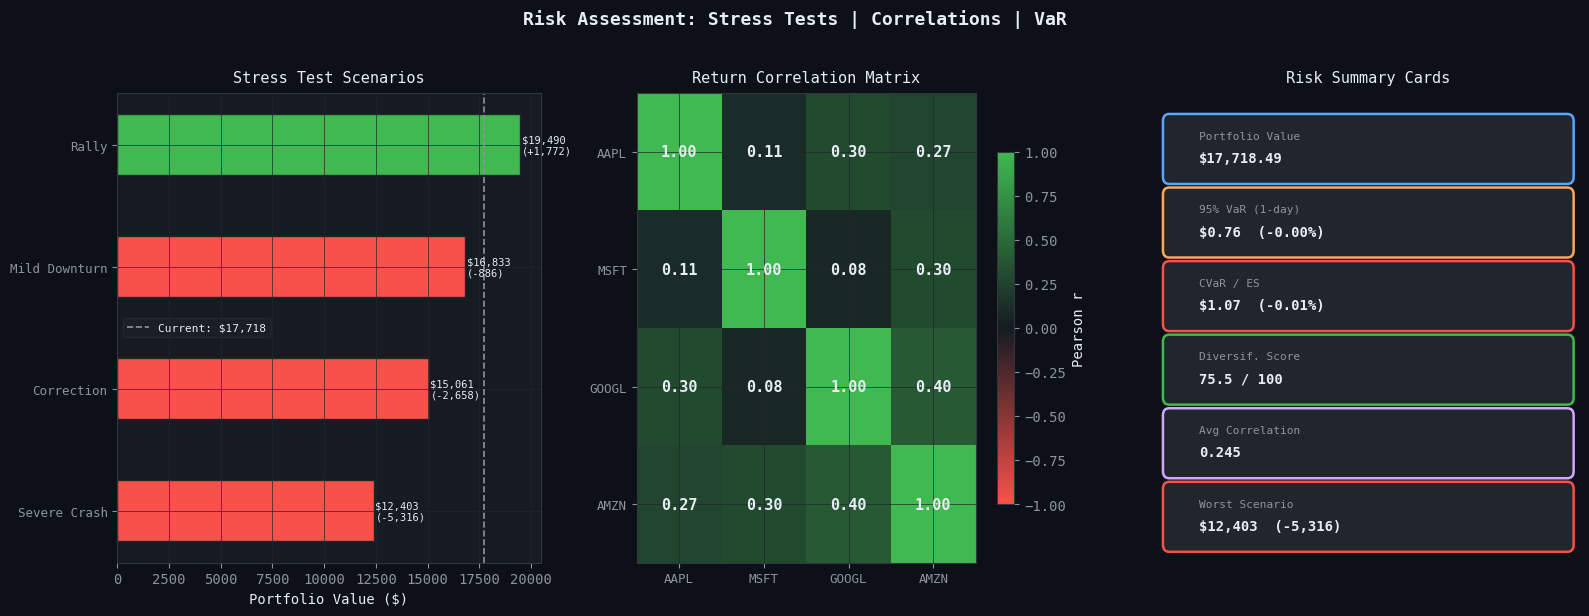

Chart saved → risk_report.png
Word report saved → risk_report.docx


'Risk chart + Word report generated.'

In [99]:
risk_agent = RiskAssessmentAgent(my_portfolio, confidence_level=0.95)
print(risk_agent.generate_risk_report())
# ── Tool 5: Visualise ───────────────────────────────────────────────────────
print("\n[RiskAssessmentAgent] Calling: plot_risk_report (Tool 5 — visualisation)")
risk_agent.plot_risk_report()


---
<a id='example4'></a>
## 6. Example 4: Multi-Agent System for Credit Risk

This example demonstrates how multiple agents can work together:
- Data Collection Agent
- Analysis Agent
- Decision Agent

This mimics how your research on bank supervision might work with multiple layers of analysis.

### 6.1 Define the Sub-Agents

**Sub-Agent 1 — `DataCollectionAgent`**

Fetches fundamental financial data for a company from `yfinance`: D/E ratio, current ratio, return on equity, profit margin, and beta. All downstream agents depend on this data.

In [100]:
class DataCollectionAgent:
    """Fetch key fundamental metrics for a company via yfinance."""
    def fetch_company_metrics(self, ticker):
        try:
            info = yf.Ticker(ticker).info
            return {
                'ticker':         ticker,
                'company_name':   info.get('longName',         'N/A'),
                'sector':         info.get('sector',           'N/A'),
                'market_cap':     info.get('marketCap',        0),
                'debt_to_equity': info.get('debtToEquity',     0),
                'current_ratio':  info.get('currentRatio',     0),
                'roe':            info.get('returnOnEquity',   0),
                'profit_margin':  info.get('profitMargins',    0),
                'beta':           info.get('beta',             1.0),
            }
        except Exception as e:
            return {'error': f'Failed to fetch data: {e}'}


**Sub-Agent 2 — `CreditAnalysisAgent`**

Scores three credit dimensions — leverage (D/E ratio), liquidity (current ratio), and profitability (ROE) — on a 2–5 scale. Averages the scores and maps the result to a letter rating: AAA, AA, A, BBB, or BB.

In [101]:
class CreditAnalysisAgent:
    """Score leverage, liquidity & profitability → letter credit rating."""
    def analyze_credit_metrics(self, data):
        if 'error' in data: return data
        de  = data.get('debt_to_equity', 0)
        cr  = data.get('current_ratio',  0)
        roe = data.get('roe', 0) * 100
        d_s = 5 if de<50  else 4 if de<100  else 3 if de<200 else 2
        l_s = 5 if cr>2   else 4 if cr>1.5  else 3 if cr>1   else 2
        p_s = 5 if roe>15 else 4 if roe>10  else 3 if roe>5  else 2
        avg = np.mean([d_s, l_s, p_s])
        lbl = {5: 'Excellent', 4: 'Good', 3: 'Fair', 2: 'Poor'}
        return {
            'ticker': data['ticker'], 'company_name': data['company_name'],
            'debt_score': lbl[d_s], 'liquidity_score': lbl[l_s], 'profitability_score': lbl[p_s],
            'overall_rating': ('AAA' if avg>=4.5 else 'AA' if avg>=4 else
                               'A'   if avg>=3.5 else 'BBB' if avg>=3 else 'BB'),
            'average_score': round(avg, 2),
        }


**Sub-Agent 3 — `CreditDecisionAgent`**

Translates the letter rating into a lending decision: Approved (AAA/AA/A), Conditional (BBB), or Declined (BB and below). Also sets the applicable interest rate and maximum approved amount.

In [102]:
class CreditDecisionAgent:
    """Map credit rating → APPROVED / CONDITIONAL / DECLINED with terms."""
    _RULES = {
        'AAA': ('APPROVED',    4.5, 1.5, 'Excellent creditworthiness'),
        'AA':  ('APPROVED',    4.5, 1.5, 'Excellent creditworthiness'),
        'A':   ('APPROVED',    6.0, 1.2, 'Good creditworthiness'),
        'BBB': ('CONDITIONAL', 8.0, 1.0, 'Fair credit; may require additional collateral'),
    }
    def make_decision(self, analysis, loan_amount):
        if 'error' in analysis: return {'decision': 'DECLINED', 'reason': 'Insufficient data'}
        rating = analysis['overall_rating']
        dec, rate, mult, reason = self._RULES.get(
            rating, ('DECLINED', None, 0, 'Creditworthiness below threshold'))
        return {
            'ticker': analysis['ticker'], 'company_name': analysis['company_name'],
            'credit_rating': rating, 'decision': dec,
            'requested_amount': loan_amount,
            'approved_amount':  loan_amount * mult if dec in ('APPROVED', 'CONDITIONAL') else 0,
            'interest_rate': rate, 'reason': reason,
            'conditions': 'Additional collateral required' if dec == 'CONDITIONAL' else None,
        }


**Sub-Agent 4 — `VisualizationAgent`**

A dedicated visualisation sub-agent in the credit-risk pipeline. It receives the accumulated
`results_cache` from the orchestrator (raw metrics + analysis + decision for every applicant)
and renders a 5-panel credit dashboard: score bars, radar chart, D/E + current ratio,
ROE comparison, and colour-coded lending decision cards.

The orchestrator exposes `visualize_all_applications()` which delegates to this agent — 
keeping the visualisation concern cleanly separated from data collection, analysis, and decisions.

In [103]:
class VisualizationAgent:
    """Sub-Agent 4: Renders credit assessment results as dashboard + Word report."""

    def plot_credit_assessment(self, results_cache):
        """5-panel credit dashboard (.png) + Word report (.docx) from results_cache."""
        from docx.shared import Inches
        if not results_cache: return "No results to visualise."
        tks4  = list(results_cache.keys())
        _s2n  = {'Poor': 2, 'Fair': 3, 'Good': 4, 'Excellent': 5}
        _lbl  = {2: 'Poor', 3: 'Fair', 4: 'Good', 5: 'Excellent'}
        _dc   = {'APPROVED': _PAL[1], 'CONDITIONAL': _PAL[4], 'DECLINED': _PAL[2]}
        _rc   = {'AA': _PAL[1], 'BBB': _PAL[4], 'BB': _PAL[2], 'A': _PAL[0], 'AAA': _PAL[1]}
        scores = {t: [_s2n[results_cache[t]['analysis'][k]]
                      for k in ('debt_score', 'liquidity_score', 'profitability_score')]
                  for t in tks4}

        # ── CHART ────────────────────────────────────────────────────────
        fig = plt.figure(figsize=(18, 10), facecolor='#0d1117')
        gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.50, wspace=0.38)

        # Panel 0: Grouped score bars
        ax0  = fig.add_subplot(gs[0, :2])
        dims = ['Debt\n(D/E)', 'Liquidity\n(Current Ratio)', 'Profitability\n(ROE)']
        x4   = np.arange(3); w4 = 0.25
        for i, (t, col) in enumerate(zip(tks4, _PAL)):
            b = ax0.bar(x4+(i-1)*w4, scores[t], width=w4, color=col,
                        edgecolor='#21262d', linewidth=0.8, label=t, alpha=0.92)
            for bar, val in zip(b, scores[t]):
                ax0.text(bar.get_x()+bar.get_width()/2, val+0.06, _lbl[val],
                         ha='center', va='bottom', fontsize=7.5, color='#e6edf3')
        ax0.set_xticks(x4); ax0.set_xticklabels(dims, fontsize=10)
        ax0.set_yticks([2, 3, 4, 5]); ax0.set_ylim(0, 6.5); ax0.legend(framealpha=0.4)
        ax0.set_yticklabels(['2 — Poor', '3 — Fair', '4 — Good', '5 — Excellent'], fontsize=9)
        ax0.set_title('Credit Score by Dimension', fontsize=11, pad=8)

        # Panel 1: Radar
        ax1    = fig.add_subplot(gs[0, 2], polar=True)
        angles = np.linspace(0, 2*np.pi, 3, endpoint=False).tolist() + [0]
        for t, col in zip(tks4, _PAL):
            vals = scores[t] + [scores[t][0]]
            ax1.plot(angles, vals, color=col, lw=2.2, label=t)
            ax1.fill(angles, vals, color=col, alpha=0.10)
        ax1.set_xticks(angles[:-1])
        ax1.set_xticklabels(['Debt', 'Liquidity', 'Profitability'], fontsize=10, fontweight='bold')
        ax1.set_yticks([2, 3, 4, 5]); ax1.set_yticklabels(['2', '3', '4', '5'], fontsize=7)
        ax1.set_ylim(0, 5.5); ax1.grid(color='#30363d', lw=0.6); ax1.set_facecolor('#161b22')
        ax1.legend(loc='upper right', bbox_to_anchor=(1.35, 1.12), framealpha=0.4)
        ax1.set_title('Scorecard Radar', fontsize=11, pad=22)

        # Panel 2: Leverage & liquidity
        ax2  = fig.add_subplot(gs[1, 0]); ax2b = ax2.twinx()
        de   = [results_cache[t]['raw']['debt_to_equity'] for t in tks4]
        cr   = [results_cache[t]['raw']['current_ratio']  for t in tks4]
        x3   = np.arange(len(tks4)); w3 = 0.35
        ax2.bar(x3-w3/2,  de, width=w3, color=_PAL[2], alpha=0.85, edgecolor='#21262d', label='D/E')
        ax2b.bar(x3+w3/2, cr, width=w3, color=_PAL[0], alpha=0.85, edgecolor='#21262d', label='Curr. Ratio')
        ax2.set_xticks(x3); ax2.set_xticklabels(tks4)
        ax2.set_ylabel('D/E Ratio', color=_PAL[2], fontsize=9)
        ax2b.set_ylabel('Current Ratio', color=_PAL[0], fontsize=9)
        ax2.set_title('Leverage & Liquidity Metrics', fontsize=11, pad=8)
        for xi, (d, c) in enumerate(zip(de, cr)):
            ax2.text(xi-w3/2, d+1, f'{d:.0f}', ha='center', fontsize=8, color='#e6edf3', fontweight='bold')
            ax2b.text(xi+w3/2, c+0.02, f'{c:.2f}', ha='center', fontsize=8, color='#e6edf3', fontweight='bold')
        h1, l1 = ax2.get_legend_handles_labels(); h2, l2 = ax2b.get_legend_handles_labels()
        ax2.legend(h1+h2, l1+l2, framealpha=0.4, fontsize=8, loc='upper right')

        # Panel 3: ROE
        ax3   = fig.add_subplot(gs[1, 1])
        roe   = [results_cache[t]['raw']['roe']*100 for t in tks4]
        b3    = ax3.bar(tks4, roe,
                        color=[_PAL[1] if r>15 else _PAL[4] if r>5 else _PAL[2] for r in roe],
                        edgecolor='#21262d', width=0.48, alpha=0.9)
        ax3.axhline(15, color=_PAL[1], lw=0.9, ls='--', label='Excellent ≥15%')
        ax3.axhline(5,  color=_PAL[4], lw=0.9, ls=':',  label='Fair ≥5%')
        ax3.set_ylabel('ROE (%)'); ax3.set_title('Return on Equity (%)', fontsize=11, pad=8)
        ax3.legend(framealpha=0.4, fontsize=8)
        for bar, v in zip(b3, roe):
            ax3.text(bar.get_x()+bar.get_width()/2, v+0.5, f'{v:.1f}%',
                     ha='center', va='bottom', fontsize=10, fontweight='bold', color='#e6edf3')

        # Panel 4: Lending decision summary cards
        ax4 = fig.add_subplot(gs[1, 2]); ax4.axis('off')
        for i, t in enumerate(tks4):
            res = results_cache[t]; dec = res['decision']; an = res['analysis']
            yb  = 0.92 - i*0.305
            dc  = _dc.get(dec['decision'], _PAL[0]); rc = _rc.get(an['overall_rating'], _PAL[0])
            ax4.add_patch(mpatches.FancyBboxPatch(
                (0.02, yb-0.27), 0.96, 0.285, boxstyle='round,pad=0.015',
                facecolor='#21262d', edgecolor=dc, linewidth=2.2, transform=ax4.transAxes))
            ax4.text(0.08, yb-0.03, t, fontsize=14, fontweight='bold',
                     color='#e6edf3', transform=ax4.transAxes)
            ax4.text(0.38, yb-0.03, an['overall_rating'], fontsize=14,
                     fontweight='bold', color=rc, transform=ax4.transAxes)
            ax4.text(0.56, yb-0.03, dec['decision'], fontsize=10,
                     fontweight='bold', color=dc, transform=ax4.transAxes)
            rate = dec['interest_rate']
            ax4.text(0.08, yb-0.12,
                     f"Approved: ${dec['approved_amount']:,.0f}   Rate: {rate if rate else 'N/A'}{'%' if rate else ''}",
                     fontsize=8.5, color='#8b949e', transform=ax4.transAxes)
            ax4.text(0.08, yb-0.20, f"Score: {an['average_score']:.2f} / 5.00",
                     fontsize=8, color='#8b949e', transform=ax4.transAxes)
        ax4.set_title('Lending Decisions', fontsize=11, pad=8)

        fig.suptitle(f'Credit Risk Dashboard — {len(tks4)} Applications',
                     fontsize=14, fontweight='bold', color='#e6edf3', y=1.01)
        _save_fig('credit_dashboard.png')

        # ── WORD REPORT ──────────────────────────────────────────────────
        doc = _new_doc('Credit Risk Assessment Report',
                       f'Applications: {" | ".join(tks4)}  ·  Generated: {datetime.now():%Y-%m-%d}')

        for t in tks4:
            res  = results_cache[t]; raw = res['raw']; an = res['analysis']; dec = res['decision']
            rate = dec['interest_rate']
            doc.add_heading(f'{raw["company_name"]}  ({t})', 2)
            doc.add_paragraph(f'Sector: {raw["sector"]}  ·  '
                               f'Market Cap: ${raw["market_cap"]:,.0f}  ·  Beta: {raw["beta"]:.2f}')
            _doc_table(doc, ['D/E Ratio', 'Current Ratio', 'ROE (%)', 'Profit Margin (%)'],
                       [[f"{raw['debt_to_equity']:.2f}", f"{raw['current_ratio']:.2f}",
                         f"{raw['roe']*100:.2f}%", f"{raw['profit_margin']*100:.2f}%"]])
            _doc_table(doc, ['Debt Score', 'Liquidity Score', 'Profitability Score', 'Rating'],
                       [[an['debt_score'], an['liquidity_score'],
                         an['profitability_score'], an['overall_rating']]])
            _doc_table(doc, ['Decision', 'Approved ($)', 'Interest Rate', 'Conditions'],
                       [[dec['decision'],
                         f"${dec['approved_amount']:,.0f}" if dec['approved_amount'] else 'N/A',
                         f"{rate:.2f}%" if rate else 'N/A',
                         dec['conditions'] or 'None']])
            report_text = res.get('report_text', '')
            if report_text:
                doc.add_heading('Full Assessment', 3)
                doc.add_paragraph(report_text)
            doc.add_paragraph('')

        doc.add_heading('Summary Comparison', 2)
        _doc_table(doc, ['Ticker', 'Avg Score', 'Rating', 'Decision', 'Rate'],
                   [[t,
                     f"{results_cache[t]['analysis']['average_score']:.2f}",
                     results_cache[t]['analysis']['overall_rating'],
                     results_cache[t]['decision']['decision'],
                     f"{results_cache[t]['decision']['interest_rate']:.2f}%"
                     if results_cache[t]['decision']['interest_rate'] else 'N/A']
                    for t in tks4])

        doc.add_heading('Credit Dashboard Chart', 2)
        doc.add_picture('credit_dashboard.png', width=Inches(6.0))

        doc.save('credit_dashboard.docx')
        print("Chart saved → credit_dashboard.png\nWord report saved → credit_dashboard.docx")
        return f"Credit dashboard + Word report saved  ({len(tks4)} applications)."


### 6.2 Define the Orchestrator

**`CreditRiskOrchestrator`**

Owns and sequences the three agents above. `process_credit_application(ticker, loan_amount)` runs the full pipeline — data collection → analysis → decision — and assembles the formatted report. This is the only class students need to call.

In [104]:
class CreditRiskOrchestrator:
    """Sequences 4 agents: Data → Analysis → Decision → Visualisation."""
    def __init__(self):
        self.data_agent     = DataCollectionAgent()
        self.analysis_agent = CreditAnalysisAgent()
        self.decision_agent = CreditDecisionAgent()
        self.viz_agent      = VisualizationAgent()   # ← Sub-Agent 4
        self.results_cache  = {}                     # accumulate across applications

    def process_credit_application(self, ticker, loan_amount):
        sep = '='*70
        print(f"[DataCollectionAgent]  Fetching {ticker}...")
        cd = self.data_agent.fetch_company_metrics(ticker)
        if 'error' in cd: return f"Error: {cd['error']}"
        print("[CreditAnalysisAgent]  Scoring creditworthiness...")
        an = self.analysis_agent.analyze_credit_metrics(cd)
        print("[CreditDecisionAgent]  Making lending decision...")
        dec = self.decision_agent.make_decision(an, loan_amount)
        # build report text first so we can store it
        r  = f"\n{sep}\nCREDIT RISK ASSESSMENT\n{sep}\n\n"
        r += f"Company : {cd['company_name']} ({ticker})\n"
        r += f"Sector  : {cd['sector']}   Market Cap: ${cd['market_cap']:,.0f}\n\n"
        r += "FINANCIAL METRICS:\n" + '-'*70 + '\n'
        r += (f"Debt-to-Equity: {cd['debt_to_equity']:.2f}   "
              f"Current Ratio: {cd['current_ratio']:.2f}\n")
        r += (f"ROE: {cd['roe']*100:.2f}%   "
              f"Profit Margin: {cd['profit_margin']*100:.2f}%   "
              f"Beta: {cd['beta']:.2f}\n\n")
        r += f"CREDIT ANALYSIS:\n{sep}\n"
        r += f"Debt Management : {an['debt_score']}\n"
        r += f"Liquidity       : {an['liquidity_score']}\n"
        r += f"Profitability   : {an['profitability_score']}\n"
        r += f"Rating          : {an['overall_rating']}  (avg {an['average_score']:.2f}/5.00)\n\n"
        r += f"LENDING DECISION:\n{sep}\n"
        r += f"Requested : ${dec['requested_amount']:,.2f}   Decision: {dec['decision']}\n"
        if dec['decision'] in ('APPROVED', 'CONDITIONAL'):
            r += f"Approved  : ${dec['approved_amount']:,.2f}   Rate: {dec['interest_rate']:.2f}%\n"
        r += f"Reason    : {dec['reason']}\n"
        if dec['conditions']: r += f"Conditions: {dec['conditions']}\n"
        self.results_cache[ticker] = {'raw': cd, 'analysis': an, 'decision': dec,
                                      'report_text': r + sep + '\n'}

        return self.results_cache[ticker]['report_text']

    def visualize_all_applications(self):
        """Sub-Agent 4 (VisualizationAgent): render dashboard for all processed applications."""
        tks = list(self.results_cache.keys())
        print(f"[VisualizationAgent]   Rendering credit dashboard for {tks} ...")
        return self.viz_agent.plot_credit_assessment(self.results_cache)

print("Multi-agent credit risk system ready  "
      "(Sub-agents: Data | Analysis | Decision | Visualisation).")


Multi-agent credit risk system ready  (Sub-agents: Data | Analysis | Decision | Visualisation).


### 6.3 Test the System

**Test — Process a Credit Application (AAPL)**

The orchestrator runs the full three-agent pipeline end-to-end: DataCollectionAgent fetches live financials, CreditAnalysisAgent scores each dimension and assigns an overall rating, CreditDecisionAgent approves, conditions, or declines the loan. Printed agent tags let students trace which agent produced each step.

In [105]:
orchestrator = CreditRiskOrchestrator()
print(orchestrator.process_credit_application("AAPL", loan_amount=1_000_000))


[DataCollectionAgent]  Fetching AAPL...
[CreditAnalysisAgent]  Scoring creditworthiness...
[CreditDecisionAgent]  Making lending decision...

CREDIT RISK ASSESSMENT

Company : Apple Inc. (AAPL)
Sector  : Technology   Market Cap: $4,589,945,880,576

FINANCIAL METRICS:
----------------------------------------------------------------------
Debt-to-Equity: 79.55   Current Ratio: 1.07
ROE: 141.47%   Profit Margin: 27.15%   Beta: 1.06

CREDIT ANALYSIS:
Debt Management : Good
Liquidity       : Fair
Profitability   : Excellent
Rating          : AA  (avg 4.00/5.00)

LENDING DECISION:
Requested : $1,000,000.00   Decision: APPROVED
Approved  : $1,500,000.00   Rate: 4.50%
Reason    : Excellent creditworthiness



**Test — Process a Second Application (TSLA)**

Runs the same three-agent pipeline on Tesla. Comparing the AAPL and TSLA outputs is instructive: despite Apple's global brand, its high leverage and low current ratio produce a lower credit score than Tesla's cleaner balance sheet — a good discussion point about the limits of purely quantitative credit models.

In [106]:
print(orchestrator.process_credit_application("TSLA", loan_amount=500_000))


[DataCollectionAgent]  Fetching TSLA...
[CreditAnalysisAgent]  Scoring creditworthiness...
[CreditDecisionAgent]  Making lending decision...

CREDIT RISK ASSESSMENT

Company : Tesla, Inc. (TSLA)
Sector  : Consumer Cyclical   Market Cap: $1,660,405,547,008

FINANCIAL METRICS:
----------------------------------------------------------------------
Debt-to-Equity: 18.74   Current Ratio: 2.04
ROE: 4.90%   Profit Margin: 3.95%   Beta: 1.79

CREDIT ANALYSIS:
Debt Management : Excellent
Liquidity       : Excellent
Profitability   : Poor
Rating          : AA  (avg 4.00/5.00)

LENDING DECISION:
Requested : $500,000.00   Decision: APPROVED
Approved  : $750,000.00   Rate: 4.50%
Reason    : Excellent creditworthiness



**Test — Process a Third Application (CCL — Carnival Corporation)**

Carnival Corporation carries very high debt (~\$24 B taken on during COVID-19) and a current ratio of only ~0.32, yet its profitability has recovered strongly (ROE ≈ 22 %). Watch how the multi-agent system handles a case where balance-sheet risk and profitability pull in opposite directions — the **CONDITIONAL** outcome reflects this tension.

> **Discussion point:** CCL scores *Poor* on both leverage and liquidity but *Excellent* on profitability. The average score of 3.0 sits exactly on the BBB boundary. Is CONDITIONAL the right call? What factors might a human loan officer add that the model ignores — e.g. sector cyclicality, refinancing risk, or the quality of collateral?

In [107]:
print(orchestrator.process_credit_application("CCL", loan_amount=500_000))

print("""
MODEL INSIGHT — Why CCL lands at BBB / CONDITIONAL
═══════════════════════════════════════════════════
  Debt score      : Poor       (2) — D/E ≈ 200, reflecting ~$24B in COVID-era debt
  Liquidity score : Poor       (2) — Current ratio ≈ 0.32; very limited buffer
  Profitability   : Excellent  (5) — ROE ≈ 22%; earnings have recovered strongly
  Average         : 3.0  →  BBB  →  CONDITIONAL

Key takeaways:
  • Strong profitability alone does not guarantee repayment capacity.
  • Real credit models add qualitative overlays (sector cyclicality, debt maturity).
  • CCL's actual market rating (BB+/Ba1) confirms the model is directionally right.
  • Compare AAPL (AA) and TSLA (AA) — all three differ in which dimension drives the score.
""")


[DataCollectionAgent]  Fetching CCL...
[CreditAnalysisAgent]  Scoring creditworthiness...
[CreditDecisionAgent]  Making lending decision...

CREDIT RISK ASSESSMENT

Company : Carnival Corporation Ltd. (CCL)
Sector  : Consumer Cyclical   Market Cap: $38,700,802,048

FINANCIAL METRICS:
----------------------------------------------------------------------
Debt-to-Equity: 203.90   Current Ratio: 0.30
ROE: 27.85%   Profit Margin: 11.48%   Beta: 2.33

CREDIT ANALYSIS:
Debt Management : Poor
Liquidity       : Poor
Profitability   : Excellent
Rating          : BBB  (avg 3.00/5.00)

LENDING DECISION:
Requested : $500,000.00   Decision: CONDITIONAL
Approved  : $500,000.00   Rate: 8.00%
Reason    : Fair credit; may require additional collateral
Conditions: Additional collateral required


MODEL INSIGHT — Why CCL lands at BBB / CONDITIONAL
═══════════════════════════════════════════════════
  Debt score      : Poor       (2) — D/E ≈ 200, reflecting ~$24B in COVID-era debt
  Liquidity score : Poor

#### Sub-Agent 4 — Credit Dashboard

Now that all three applications have been processed and cached by the orchestrator, the `VisualizationAgent` renders a unified dashboard in a single call.

[VisualizationAgent]   Rendering credit dashboard for ['AAPL', 'TSLA', 'CCL'] ...


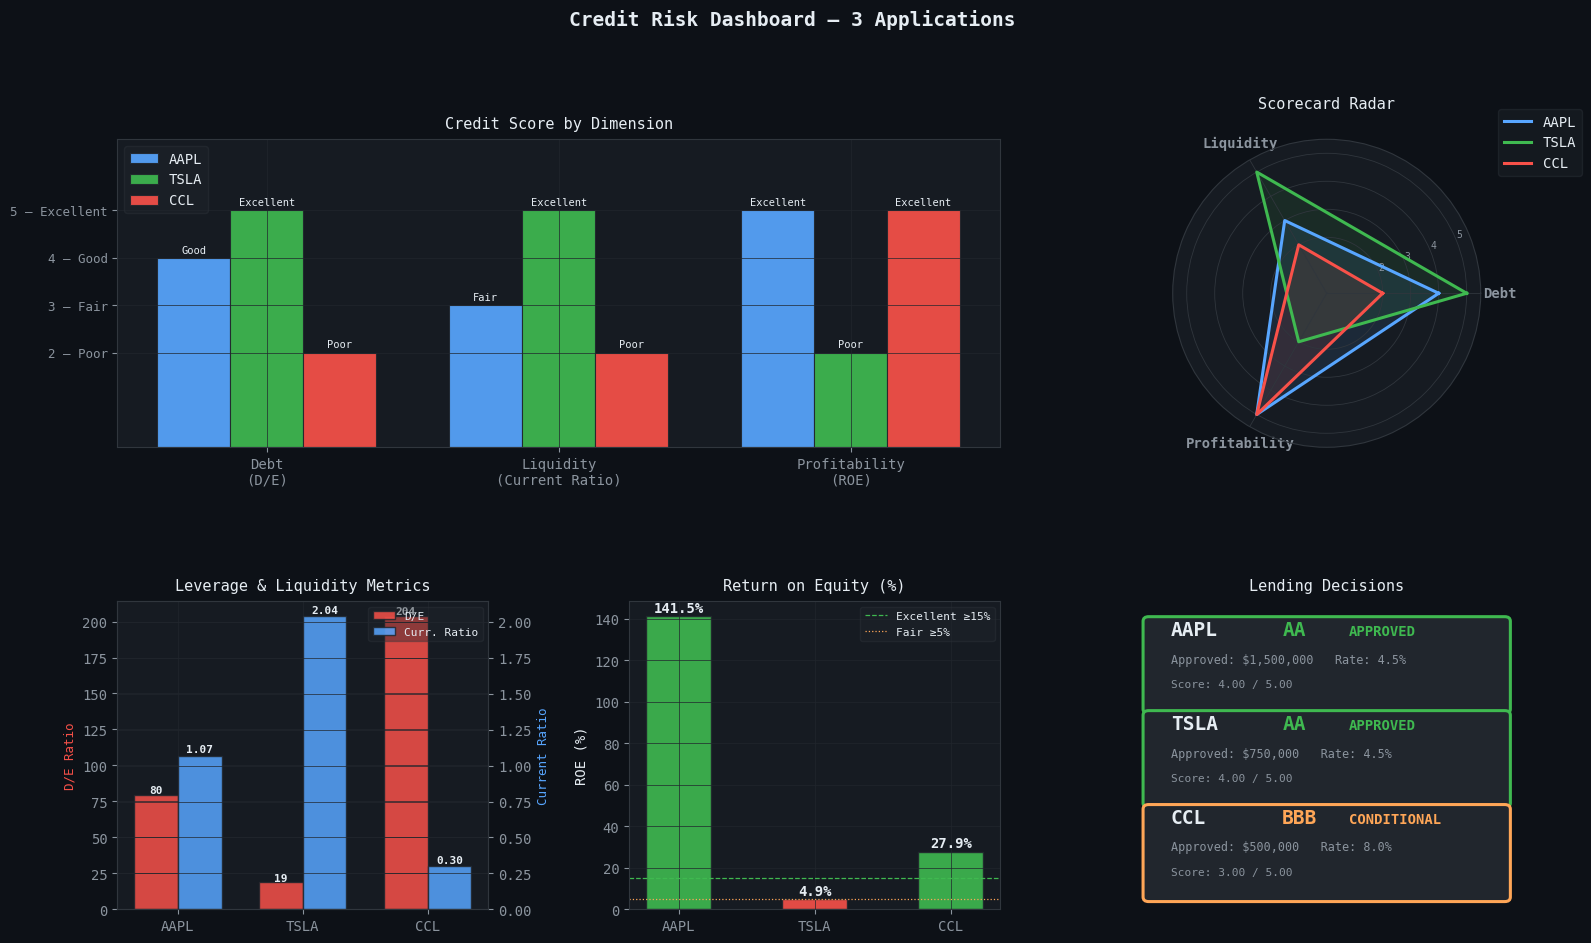

Chart saved → credit_dashboard.png
Word report saved → credit_dashboard.docx
Credit dashboard + Word report saved  (3 applications).


In [108]:
# ── Sub-Agent 4: Visualise all processed applications ─────────────────────
print(orchestrator.visualize_all_applications())


---
<a id='advanced'></a>
## 7. Advanced Topics and Best Practices

### 7.1 Key Principles for AI Agents in Finance

1. **Transparency & Explainability**
   - Always provide reasoning for decisions
   - Document data sources and methodologies
   - Enable audit trails

2. **Risk Management**
   - Implement human-in-the-loop for critical decisions
   - Set clear limits and thresholds
   - Regular validation and backtesting

3. **Data Quality**
   - Validate inputs
   - Handle missing data appropriately
   - Monitor data freshness

4. **Compliance & Regulation**
   - Follow regulatory requirements
   - Maintain documentation
   - Regular compliance reviews

5. **Continuous Improvement**
   - Monitor performance metrics
   - Collect feedback
   - Regular model updates

### 7.2 LLM Integration — What We Built

Throughout this notebook we used **real LLM calls** (not keyword matching).
Here is a summary of the integration pattern:

| Layer | What it does |
|---|---|
| `LLM_BACKEND` config | Switches between Ollama, Groq, or OpenAI in one line |
| `call_llm(prompt, system_prompt)` | Single function that routes to the active backend |
| System prompt | Describes tools + expected `TOOL: name(args)` format |
| First LLM call | Decides which tool to invoke |
| Tool execution | Fetches live financial data |
| Second LLM call | Interprets data and writes the final answer |

**Commercially-free options used in this notebook:**
- `mistral` / `mixtral-8x7b` — Apache 2.0
- `phi4` — MIT
- `qwen2.5` — Apache 2.0
- `deepseek-r1` — MIT

To switch models, change `LLM_BACKEND` and the model name in the config cell.
All downstream code (`call_llm`, agents) works unchanged.

### 7.3 Advanced Agent Architectures

#### ReAct (Reasoning + Acting)
- Interleave reasoning and action steps
- Allows for dynamic planning

#### Chain-of-Thought
- Break complex problems into steps
- Show intermediate reasoning

#### Multi-Agent Collaboration
- Specialized agents for different tasks
- Coordinator agent manages workflow
- Agents can critique each other's work

#### Memory Systems
- Short-term: Conversation context
- Long-term: Vector databases (embeddings)
- Entity memory: Track entities and relationships

## Conclusion

AI agents represent a powerful paradigm for automating financial analysis and decision-making. Key takeaways:

1. **Agents = Perception + Reasoning + Action**
   - Use LLMs for reasoning
   - Tools extend capabilities
   - Memory enables context

2. **Start Simple, Scale Complexity**
   - Begin with single-agent, single-tool systems
   - Add tools and agents as needed
   - Focus on clear objectives

3. **Domain Expertise Matters**
   - Financial knowledge is critical
   - Validate agent outputs
   - Maintain human oversight

4. **Ethics & Compliance First**
   - Transparency in decision-making
   - Regular audits and validation
   - Adherence to regulations

The future of finance will increasingly involve AI agents working alongside human experts. Understanding how to build, deploy, and supervise these agents is becoming an essential skill for financial professionals and researchers.